In [1]:
import re
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import find_peaks, butter, filtfilt, detrend, windows
import matplotlib.pyplot as plt

# Material properties (Al 6061 by default)
E_GPa = 69.0      # GPa (Young's modulus)
rho = 2700.0      # kg/m^3 (density)

# Section geometry (bending about h)
b_mm = 11.4       # mm (width b)
h_mm = 0.70       # mm (height h)

# Processing
FREQ_MIN_HZ = 0.5
HIGHPASS_CUTOFF_HZ = 20
HIGHPASS_ORDER = 1

# ---- Theoretical: cantilever with rectangular cross-section ----
# Roots of cosh(βL) cos(βL) = -1 for an ideal cantilever:
BETA_L = {
    1: 1.875104068711961,
    2: 4.694091132974174,
    3: 7.854757438237612,
    4: 10.995540734875466
}

In [2]:
# Folder roots by length
ROOT_1_5 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_5cm"
ROOT_1_6 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_6cm"
ROOT_1_7 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_7cm"
ROOT_1_8 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_8cm"
ROOT_1_9 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_9cm"
ROOT_1_10 = r"C:\\Users\\axelr\\OneDrive\\Escritorio\\Proyecto3\\notebooks\\analysis-codes\\healthy_beam_lectures\\healthy_beam_10cm"

# Length map -> (root, final_inclusive_index, perturbations_per_file)
LENGTH_CONFIG = {
    0.05: (ROOT_1_5, 25, 2),   # 25 folders (0000..0024), 2 perturbations = 50
    0.06: (ROOT_1_6, 25, 2),
    0.07: (ROOT_1_7, 25, 2),
    0.08: (ROOT_1_8, 25, 2),
    0.09: (ROOT_1_9, 49, 1),   # 50 folders (0000..0049), 1 perturbation
    0.10: (ROOT_1_10, 49, 1),
}

In [3]:
def read_sampling_interval_from_header(path):
    """
    Searches inside the Tektronix CSV file for the sampling interval
    (Sample Interval) given in the first lines of the file header.
    Returns the value in seconds, or None if it is not found.
    """
    try:
        with open(path, 'r', encoding='utf-8', errors='ignore') as f:
            for _ in range(80):
                line = f.readline()
                if not line:
                    break
                if "Sample Interval" in line:
                    m = re.search(r'([-+]?\d*\.?\d+(?:[eE][-+]?\d+)?)', line)
                    if m:
                        return float(m.group(1))
    except Exception:
        pass
    return None

def load_tektronix_csv_columns_DE(path):
    """
    Loads data from a CSV file generated by the Tektronix oscilloscope.
    Returns two NumPy vectors:
      D -> time column (s)
      E -> voltage column (V)
    Ignores empty cells and converts text to numeric values.
    """
    df = pd.read_csv(path, header=None, engine="python", sep=r"[,\t;]", skip_blank_lines=True)
    if df.shape[1] < 5:
        df = pd.read_csv(path, header=None)
    D = pd.to_numeric(df.iloc[:, 3], errors='coerce')  # time (s)
    E = pd.to_numeric(df.iloc[:, 4], errors='coerce')  # voltage (V)
    mask = (~D.isna()) & (~E.isna())
    return D[mask].to_numpy(), E[mask].to_numpy()

def compute_fs_from_header_or_time(t, path):
    """
    Computes the sampling frequency (fs) of the data.
    It first tries to read it from the file header.
    If unavailable, it estimates it as the inverse of the mean sampling interval.
    """
    dt_header = read_sampling_interval_from_header(path)
    if dt_header and dt_header > 0:
        return 1.0 / dt_header
    dt = np.median(np.diff(t))
    return 1.0 / dt

def butter_highpass_filter(x, fs, fc=HIGHPASS_CUTOFF_HZ, order=HIGHPASS_ORDER):
    """
    Applies a Butterworth high-pass filter to remove low-frequency components
    (for example, background noise or DC component).
    fc : cutoff frequency (Hz)
    order : filter order
    """
    b, a = butter(order, fc / (fs / 2), btype='highpass')
    return filtfilt(b, a, x)

def fft_single_sided(x, fs):
    """
    Computes the single-sided Fast Fourier Transform (FFT) using a Hann window.
    Normalizes the signal, removes linear trends, and returns the dimensionless spectral magnitude.
    Returns:
      freqs -> frequency axis (Hz)
      mag   -> magnitude (dimensionless)
    """
    x = detrend(x, type='linear')
    m = np.max(np.abs(x))
    x = x if m == 0 else x / m
    N = len(x)
    w = windows.hann(N, sym=False)
    X = np.fft.rfft(x * w)
    freqs = np.fft.rfftfreq(N, 1 / fs)
    scale = 2.0 / np.sum(w)
    mag = np.abs(X) * scale
    if mag.size > 0:
        mag[0] /= 2.0
    if (N % 2 == 0) and (mag.size > 1):
        mag[-1] /= 2.0
    return freqs, mag

def estimate_f0_from_spectrum(freqs, spectrum, fmin=FREQ_MIN_HZ):
    """
    Estimates the fundamental frequency (f0) from the spectrum.
    It searches for the maximum spectral value above a minimum frequency fmin (to avoid noise).
    """
    valid = freqs >= fmin
    f, s = freqs[valid], spectrum[valid]
    if f.size == 0:
        return None
    return float(f[np.argmax(s)])

def list_paths(root, final_inclusive_index):
    """
    Generates a list of full paths to CSV files from a root folder.
    Example output: ['.../ALL0000/F0000CH1.CSV', '.../ALL0001/F0001CH1.CSV', ...]
    """
    paths = []
    for k in range(final_inclusive_index + 1):
        s = f"{k:04d}"
        paths.append(str(Path(root) / f"ALL{s}" / f"F{s}CH1.CSV"))
    return paths

def cantilever_f_n(L, b_mm, h_mm, E_GPa=E_GPa, rho=rho, n=1):
    """
    Computes the theoretical frequency of mode 'n' for a cantilever beam
    (Euler-Bernoulli model for rectangular cross-section).

    Parameters:
      L  : beam length [m]
      b  : beam width [mm]
      h  : beam height or thickness [mm]
      E  : Young's modulus [GPa]
      ρ  : material density [kg/m³]

    Returns:
      Frequency of mode n in [Hz]
    """
    if n not in BETA_L:
        raise ValueError("Mode not tabulated; use n=1..4 or add your own value.")
    betaL = BETA_L[n]
    E = E_GPa * 1e9
    b = b_mm * 1e-3
    h = h_mm * 1e-3
    A = b * h
    I = b * (h ** 3) / 12.0
    return (betaL ** 2) / (2 * np.pi * L ** 2) * np.sqrt(E * I / (rho * A))

def average_spectra_by_length(L, root, final_idx, perturbations_per_file):
    """
    Processes and averages spectra by length.

    Returns:
      - 'fft_freqs'
      - 'fft_avg'
      - 'fft_avg_norm'
      - 'f0_mean'      : average experimental fundamental frequency
      - 'fs'
      - 'n_segments'
    """
    paths = list_paths(root, final_idx)

    fft_sum = None
    fft_sum_norm = None
    counter = 0

    fs_ref = None
    freqs_ref = None

    f0_values = []   # only used to compute the mean

    for path in paths:
        try:
            t, v = load_tektronix_csv_columns_DE(path)
            fs = compute_fs_from_header_or_time(t, path)
            if fs_ref is None:
                fs_ref = fs
        except Exception:
            continue

        N = len(v)
        segments = [(0, N // 2), (N // 2, N)] if perturbations_per_file == 2 else [(0, N)]

        for (i0, i1) in segments:
            seg = v[i0:i1]
            if len(seg) < 8:
                continue

            seg = butter_highpass_filter(seg, fs)
            f_fft, mag = fft_single_sided(seg, fs)

            if freqs_ref is None:
                freqs_ref = f_fft.copy()
                fft_sum = np.zeros_like(mag, dtype=float)
                fft_sum_norm = np.zeros_like(mag, dtype=float)

            if mag.shape != fft_sum.shape:
                mag = np.interp(freqs_ref, f_fft, mag)

            # f0 per segment (only for the mean)
            f0_seg = estimate_f0_from_spectrum(freqs_ref, mag, FREQ_MIN_HZ)
            if f0_seg is not None:
                f0_values.append(f0_seg)

            mmax = np.max(mag) if mag.size else 0.0
            mag_norm = mag / mmax if mmax > 0 else mag

            fft_sum += mag
            fft_sum_norm += mag_norm
            counter += 1

    if counter == 0 or len(f0_values) == 0:
        return None

    return {
        "L": L,
        "fft_freqs": freqs_ref,
        "fft_avg": fft_sum / counter,
        "fft_avg_norm": fft_sum_norm / counter,
        "f0_mean": float(np.mean(f0_values)),
        "fs": fs_ref,
        "n_segments": counter
    }

def estimate_modes(freqs, mag, fmin=FREQ_MIN_HZ, n_modes=3):
    valid = freqs >= fmin
    f = freqs[valid]
    s = mag[valid]

    # Find all peaks
    peaks, _ = find_peaks(s, height=np.max(s) * 0.02)   # 2% threshold
    if len(peaks) == 0:
        return None

    # Sort by frequency, not by magnitude
    peak_freqs = f[peaks]
    peak_freqs_sorted = np.sort(peak_freqs)

    # Return the first n modes found
    return peak_freqs_sorted[:n_modes]

L=5 cm | f0_exp≈219.672 Hz | f0_theo≈228.655 Hz | error=3.93% | n=50
L=6 cm | f0_exp≈154.040 Hz | f0_theo≈158.788 Hz | error=2.99% | n=50
L=7 cm | f0_exp≈113.224 Hz | f0_theo≈116.661 Hz | error=2.95% | n=50
L=8 cm | f0_exp≈88.008 Hz | f0_theo≈89.318 Hz | error=1.47% | n=50
L=9 cm | f0_exp≈68.096 Hz | f0_theo≈70.573 Hz | error=3.51% | n=50
L=10 cm | f0_exp≈58.200 Hz | f0_theo≈57.164 Hz | error=1.81% | n=50

=== Frequency table (by length) ===
 Length (mm)  f_theoretical (Hz)  f_experimental_mean (Hz)  n_segments  Relative error (%)
         100             57.1638                    58.200          50              1.8127
          90             70.5726                    68.096          50              3.5093
          80             89.3184                    88.008          50              1.4671
          70            116.6608                   113.224          50              2.9460
          60            158.7883                   154.040          50              2.9903
        

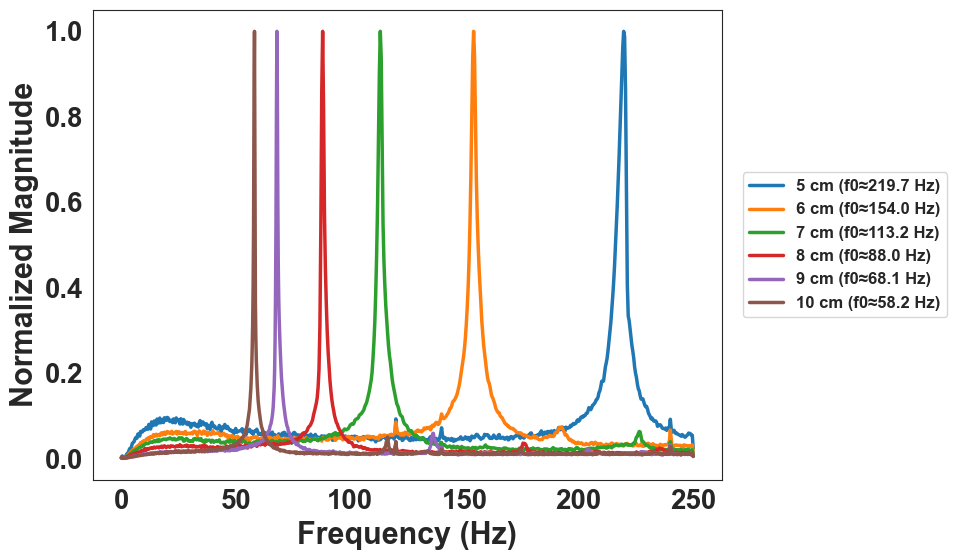

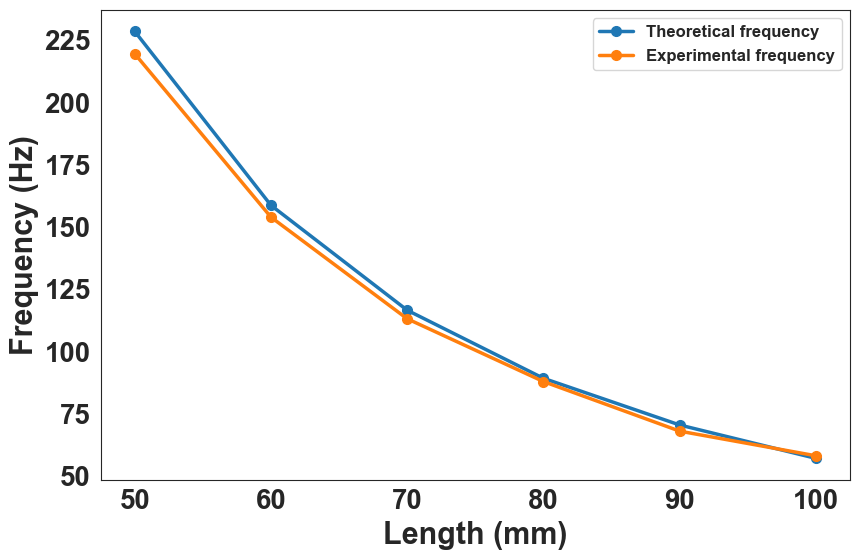

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# ------------------------------------------------
# Global plot style (publication readability)
# ------------------------------------------------
plt.rcParams.update({
    "font.size": 20,
    "font.weight": "bold",
    "axes.titlesize": 22,
    "axes.titleweight": "bold",
    "axes.labelsize": 22,
    "axes.labelweight": "bold",
    "xtick.labelsize": 20,
    "ytick.labelsize": 20,
    "legend.fontsize": 12
})

sns.set_style("white")  # remove grid

# ============================================================
# Frequency processing
# ============================================================

healthy_results_1 = []
healthy_spectra_by_L_1 = {}

for L, (root, final_idx, segs) in LENGTH_CONFIG.items():
    output = average_spectra_by_length(L, root, final_idx, segs)
    if output is None:
        print(f"Files could not be processed for L={L*100:.0f} cm")
        continue

    f0_mean = output["f0_mean"]

    f0_theoretical = cantilever_f_n(L, b_mm=b_mm, h_mm=h_mm, E_GPa=E_GPa, rho=rho, n=1)

    err_pct = abs(f0_mean - f0_theoretical) / f0_theoretical * 100.0 if f0_mean is not None else np.nan

    healthy_results_1.append({
        "Length (mm)": int(round(L * 1000)),
        "f_theoretical (Hz)": f0_theoretical,
        "f_experimental_mean (Hz)": f0_mean,
        "n_segments": output["n_segments"],
        "Relative error (%)": err_pct
    })

    healthy_spectra_by_L_1[L] = output

    print(
        f"L={L*100:.0f} cm | "
        f"f0_exp≈{f0_mean:.3f} Hz | "
        f"f0_theo≈{f0_theoretical:.3f} Hz | "
        f"error={err_pct:.2f}% | n={output['n_segments']}"
    )

# ---- Final table
df = pd.DataFrame(healthy_results_1).sort_values("Length (mm)", ascending=False)

df["f_theoretical (Hz)"] = df["f_theoretical (Hz)"].map(lambda x: round(x, 4))
df["f_experimental_mean (Hz)"] = df["f_experimental_mean (Hz)"].map(lambda x: round(x, 4))
df["Relative error (%)"] = df["Relative error (%)"].map(lambda x: round(x, 4))

print("\n=== Frequency table (by length) ===")
print(df.to_string(index=False))

df.to_csv("healthy_frequency_table.csv", index=False)
print("\nTable saved in: healthy_frequency_table.csv")

# ============================================================
# Graph 1: Average normalized FFT by length
# ============================================================

plt.figure(figsize=(10, 6))

for L, output in sorted(healthy_spectra_by_L_1.items()):
    y = output["fft_avg_norm"].copy()
    ymax = np.max(y)

    if ymax > 0:
        y = y / ymax

    plt.plot(
        output["fft_freqs"],
        y,
        linewidth=2.5,
        label=f"{int(L*100)} cm (f0≈{output['f0_mean']:.1f} Hz)"
    )

# plt.title("Average FFT by Length", fontweight='bold')
plt.xlabel("Frequency (Hz)", fontweight='bold')
plt.ylabel("Normalized Magnitude", fontweight='bold')

plt.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=True)

plt.grid(False)

plt.tight_layout()
plt.show()

# ============================================================
# Graph 2: Theoretical vs Experimental Frequency
# ============================================================

df_plot = df.sort_values("Length (mm)")

Lm = df_plot["Length (mm)"].to_numpy()
f_theoretical = df_plot["f_theoretical (Hz)"].to_numpy()
f_experimental = df_plot["f_experimental_mean (Hz)"].to_numpy()

plt.figure(figsize=(9, 6))

plt.plot(
    Lm,
    f_theoretical,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Theoretical frequency"
)

plt.plot(
    Lm,
    f_experimental,
    marker="o",
    linewidth=2.5,
    markersize=7,
    label="Experimental frequency"
)

# plt.title("Variation of the Fundamental Frequency with Length", fontweight='bold')
plt.xlabel("Length (mm)", fontweight='bold')
plt.ylabel("Frequency (Hz)", fontweight='bold')

plt.legend()

plt.grid(False)

plt.tight_layout()
plt.show()